# SiMaster quickstart

Estimate optimal bandpowers of a masked, noisy spin-0 field in ~20 lines.
See `simaster_vs_namaster.ipynb` for the NaMaster comparison and
`docs/method.md` for what happens under the hood.

/home/anze/anaconda3/envs/simaster/lib/python3.11/site-packages/astropy/config/paths.py:55: AstropyUserWarning: XDG_CONFIG_HOME is set to '/home/anze/.config', but the default location, /home/anze/.astropy/config, already exists, and takes precedence. This environment variable will be ignored.
  return set_temp_config._get_dir_path(rootname)


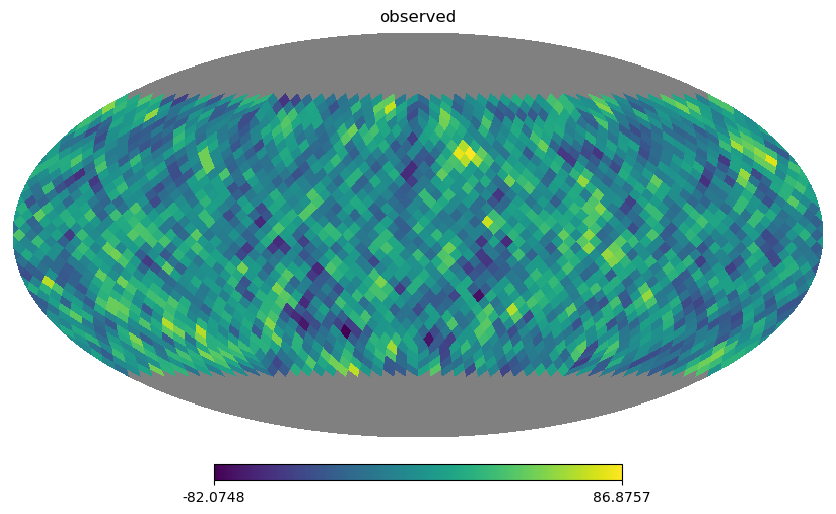

In [1]:
import os
os.environ.setdefault("XLA_PYTHON_CLIENT_PREALLOCATE", "false")
import numpy as np, healpy as hp, matplotlib.pyplot as plt
import simaster as sm

nside, lmax = 16, 47
npix = hp.nside2npix(nside)
rng = np.random.default_rng(0)

# inputs: mask, ivar, observed map  (observed = mask*signal + noise)
theta, phi = hp.pix2ang(nside, np.arange(npix))
mask = (np.abs(np.cos(theta)) < 0.8).astype(float)        # galactic-like cut
ivar = np.full(npix, 1/25.0)                              # sigma = 5 per pixel
l = np.arange(lmax+1.)
cl_true = np.where(l >= 2, 4e3/(l+10)**2, 0)
signal = hp.synfast(cl_true, nside, lmax=lmax)
observed = mask*signal + rng.normal(0, 5.0, npix)
hp.mollview(observed*np.where(mask>0, 1, np.nan), title="observed"); plt.show()

In [2]:
field = sm.Field(mask, [observed], ivar=ivar, name="g")
bins  = sm.Bins.linear(2, lmax, nlb=5)
# any reasonable fiducial works (estimates stay unbiased); take truth here
w = sm.QMLWorkspace(field, bins, {("g_0","g_0"): cl_true}, lmax=lmax,
                    fisher_mode="exact", verbose=False)
res = w.estimate()
print("bandpowers:", np.round(res.cl["g_0 x g_0"], 2))

bandpowers: [11.38  8.82  6.71  3.95  3.2   2.4   2.04  1.62  1.24  1.41]


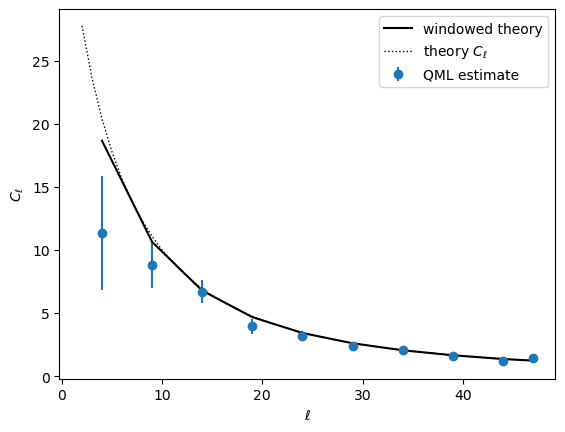

In [3]:
err = np.sqrt(np.diag(res.cov))
pred = w.predict({("g_0","g_0"): cl_true})["g_0 x g_0"]   # window-convolved theory
plt.errorbar(res.ells, res.cl["g_0 x g_0"], err, fmt="o", label="QML estimate")
plt.plot(res.ells, pred, "k-", label="windowed theory")
plt.plot(l[2:], cl_true[2:], "k:", lw=1, label="theory $C_\\ell$")
plt.xlabel("$\\ell$"); plt.ylabel("$C_\\ell$"); plt.legend(); plt.show()

## Template marginalization

Add a contaminating template with unknown amplitude; marginalize it by
passing `templates=` (covariance gains $\alpha\, t t^T$ with
$\alpha\to\infty$ by default, or set `template_alpha=1e6` for the
finite-prefactor prescription).

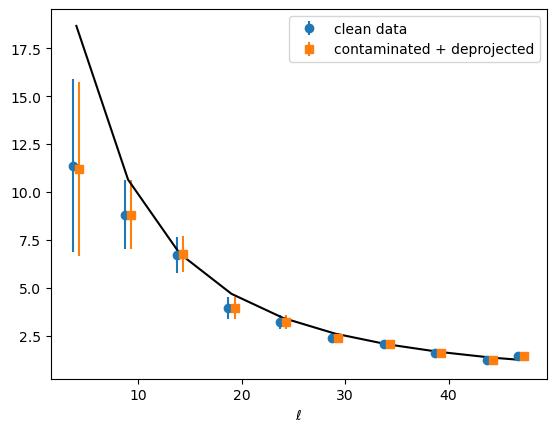

In [4]:
tmpl = hp.synfast(np.where(l>=2, 4e3/(l+3)**3, 0), nside, lmax=lmax)
contaminated = observed + 30.0*tmpl*mask
f2 = sm.Field(mask, [contaminated], ivar=ivar, name="g", templates=[tmpl*mask])
w2 = sm.QMLWorkspace(f2, bins, {("g_0","g_0"): cl_true}, lmax=lmax,
                     fisher_mode="exact", verbose=False)
res2 = w2.estimate()
plt.errorbar(res.ells-0.3, res.cl["g_0 x g_0"], err, fmt="o", label="clean data")
plt.errorbar(res2.ells+0.3, res2.cl["g_0 x g_0"],
             np.sqrt(np.diag(res2.cov)), fmt="s", label="contaminated + deprojected")
plt.plot(res.ells, pred, "k-"); plt.xlabel("$\\ell$"); plt.legend(); plt.show()